In [40]:
# 기본 설정 및 라이브러리
%matplotlib inline
import os, subprocess
# 맥에서 JAVA_HOME 이 비어있으면 자동으로 채운다 (KoNLPy 가 JVM 을 찾는 데 필요).
if not os.environ.get("JAVA_HOME"):
    try:
        os.environ["JAVA_HOME"] = subprocess.check_output(["/usr/libexec/java_home"]).decode().strip()
    except Exception:
        pass

import joblib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 한글 폰트 (맥 기본). 지정 안 하면 그래프/워드클라우드 글자가 전부 □ 로 깨진다.
FONT_PATH = "/System/Library/Fonts/Supplemental/AppleGothic.ttf"
font_manager.fontManager.addfont(FONT_PATH)
plt.rcParams["font.family"] = font_manager.FontProperties(fname=FONT_PATH).get_name()
plt.rcParams["axes.unicode_minus"] = False

## 부정 리뷰 군집화 — 불만 유형 분석

감성분석 모델이 **부정으로 예측한 리뷰**만 모아, "무엇 때문에 불만인지"를 K-Means로 유형화한다.

- 부정 선별: 별점이 아니라 **앞에서 학습한 모델의 예측**으로 고른다 → 별점 없는 새 리뷰에도 똑같이 적용 가능
- 군집화 공간: **TF-IDF**(텍스트 기반). 고차원이라 TruncatedSVD로 차원축소 후 K-Means
- 최적 군집 수 K는 Elbow + Silhouette로 점검
- 군집별 대표 키워드·워드클라우드·빈도로 **CS 개선 우선순위**를 도출

### 1. 부정 리뷰 추출 & 군집화 준비

- 앞에서 학습한 감성분석 모델로 전체 리뷰의 긍/부정을 예측하고, **부정으로 예측된 리뷰만** 골라 군집화 대상으로 삼는다. 
- 또한 군집 키워드를 "명사" 위주로 보여주기 위해, 각 단어가 명사인지 미리 판별해 둔다.

In [41]:
import joblib
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.metrics import silhouette_score
from wordcloud import WordCloud

N_CLUSTERS     = 5      # 군집 개수
SVD_COMPONENTS = 100    # 차원축소 후 차원 수
TOP_KEYWORDS   = 15     # 군집별로 볼 키워드 수
RANDOM_STATE   = 42     # 재현성 고정용

# 키워드 '표시'에서만 제외할 의미 약한 단어 (군집 계산엔 영향 없음)
DISPLAY_STOPWORDS = {
    "별로","이건","그냥","정도","느낌","부분","진짜","완전","생각","제품","상품",
    "구입","구매","주문","사용","가지","개","이","거","점","수","것","때",
}

def is_generic(term):
    return all(part in DISPLAY_STOPWORDS for part in term.split())

def top_terms(center_row, feature_names, n, is_noun):
    """군집 중심에서 가중치 높은 '명사'만, 의미 약한 단어는 건너뛰며 n개 추출"""
    out = []
    for idx in center_row.argsort()[::-1]:
        term = feature_names[idx]
        if not all(is_noun.get(p, False) for p in term.split()):
            continue
        if is_generic(term):
            continue
        out.append((term, float(center_row[idx])))
        if len(out) >= n:
            break
    return out

# ── 데이터 · 모델 · 벡터라이저 불러오기 ──
data = joblib.load("features.pkl")
X, y = data["X"], data["y"]
model = joblib.load("model.pkl")
tfidf = joblib.load("tfidf_vectorizer.pkl")  

# ── 감성분석 모델이 '부정'으로 예측한 리뷰만 추출 ──
pred = model.predict(X)
X_neg = X[pred == 0]
print(f"전체 리뷰 {X.shape[0]:,}개")
print(f"모델이 부정으로 예측: {X_neg.shape[0]:,}개  (이걸 군집화)")
print(f"(참고: 별점 기반 실제 부정 {(y==0).sum():,}개 / 모델 정확도 {(pred==y).mean():.1%})")

# ── 키워드 표시용: 각 단어가 명사인지 한 번만 판별 ──
from konlpy.tag import Okt
okt = Okt()
feature_names = tfidf.get_feature_names_out()
underlying = set()
for term in feature_names:
    underlying.update(term.split())
print(f"\n단어 {len(underlying):,}개 품사 판별 중...")
is_noun = {w: any(p == "Noun" for _, p in okt.pos(w, stem=True)) for w in underlying}
print(f"그중 명사: {sum(is_noun.values()):,}개")

전체 리뷰 198,896개
모델이 부정으로 예측: 100,120개  (이걸 군집화)
(참고: 별점 기반 실제 부정 99,266개 / 모델 정확도 90.2%)

단어 6,329개 품사 판별 중...
그중 명사: 5,172개


### 2. 차원 축소 (TruncatedSVD)

TF-IDF는 2만 차원이라 그대로 군집화하면 느리고 노이즈가 많다. TruncatedSVD로 **100차원**으로 압축한 뒤, 거리 계산이 안정되도록 정규화한다.

In [49]:
svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=RANDOM_STATE)
X_reduced = Normalizer(copy=False).fit_transform(svd.fit_transform(X_neg))
print(f"축소 후 형태: {X_reduced.shape}  (설명된 분산 합: {svd.explained_variance_ratio_.sum():.1%})")

축소 후 형태: (100120, 100)  (설명된 분산 합: 17.8%)


### 3. 적절한 군집 수(K) 점검 — Elbow & Silhouette

K를 2~8로 바꿔가며 두 지표를 본다.
- **Elbow(inertia)**: 군집 내 응집도. 꺾이는 지점이 적절한 K
- **Silhouette**: 군집 분리도. 높을수록 잘 나뉨

K=2: inertia=92053.0, silhouette=0.0187
K=3: inertia=90890.6, silhouette=0.0165
K=4: inertia=88819.0, silhouette=0.0259
K=5: inertia=87369.0, silhouette=0.0305
K=6: inertia=86085.1, silhouette=0.0330
K=7: inertia=85140.5, silhouette=0.0380
K=8: inertia=83922.4, silhouette=0.0437


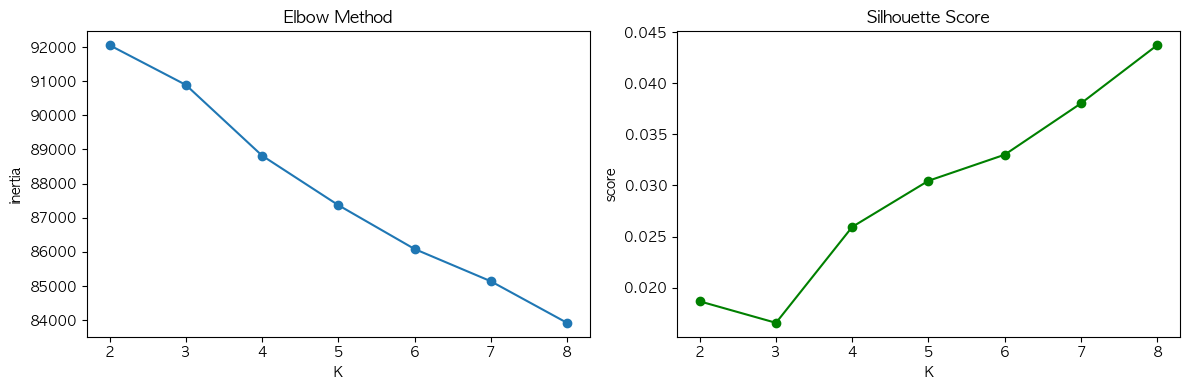

In [43]:
K_RANGE = range(2, 9)
inertias, silhouettes = [], []
for k in K_RANGE:
    km = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=3, batch_size=1024)
    labels_k = km.fit_predict(X_reduced)
    sil = silhouette_score(X_reduced, labels_k, sample_size=5000, random_state=RANDOM_STATE)
    inertias.append(km.inertia_); silhouettes.append(sil)
    print(f"K={k}: inertia={km.inertia_:.1f}, silhouette={sil:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(K_RANGE), inertias, "o-"); ax1.set_title("Elbow Method"); ax1.set_xlabel("K"); ax1.set_ylabel("inertia")
ax2.plot(list(K_RANGE), silhouettes, "o-", color="green"); ax2.set_title("Silhouette Score"); ax2.set_xlabel("K"); ax2.set_ylabel("score")
plt.tight_layout(); plt.show()

### 4. K-Means 군집화

위 점검을 토대로 `N_CLUSTERS`(=5)로 군집화한다. 부정 리뷰가 5개 불만 유형으로 묶인다.

In [44]:
km = MiniBatchKMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=3, batch_size=1024)
labels = km.fit_predict(X_reduced)
print(f"{N_CLUSTERS}개 군집으로 묶었습니다.")
for c in range(N_CLUSTERS):
    print(f"  군집 {c}: {int((labels==c).sum()):,}개")

5개 군집으로 묶었습니다.
  군집 0: 20,565개
  군집 1: 7,636개
  군집 2: 19,031개
  군집 3: 9,297개
  군집 4: 43,591개


### 5. 군집별 대표 키워드 — 불만 유형 해석

각 군집의 TF-IDF 평균 벡터에서 **전체 평균을 뺀 '고유성 점수'**로 키워드를 뽑는다. 모든 군집에 흔한 단어(반품·가격 등)는 깎이고, 그 군집만의 특징 단어가 부각된다.

In [45]:
# 원본 TF-IDF 공간에서 군집별 평균 벡터
centers_tfidf = np.vstack([
    np.asarray(X_neg[labels == c].mean(axis=0)).ravel() for c in range(N_CLUSTERS)
])
# 고유성 점수 = (이 군집 평균) - (전체 군집 평균)
centers_distinct = centers_tfidf - centers_tfidf.mean(axis=0, keepdims=True)

summary = {}
for c in range(N_CLUSTERS):
    terms = top_terms(centers_distinct[c], feature_names, TOP_KEYWORDS, is_noun)
    keywords = [t for t, _ in terms]
    size = int((labels == c).sum())
    summary[c] = {"size": size, "keywords": keywords}
    print(f"[군집 {c}] 리뷰 {size:,}개")
    print("  키워드:", ", ".join(keywords), "\n")

[군집 0] 리뷰 20,565개
  키워드: 반품, 교환, 확인, 참고, 다시, 조립, 세탁, 설치, 보고, 판매, 뻑뻑, 검수, 환불, 잘못, 다른 

[군집 1] 리뷰 7,636개
  키워드: 배송, 택배, 연락, 물건, 일주일, 최악, 기사, 전화, 배송 기사, 지연, 배송 진짜, 배송 최악, 엉망, 상태, 배송 일주일 

[군집 2] 리뷰 19,031개
  키워드: 반품, 효과, 전혀, 의사, 교환, 하나, 정품, 그냥 가격, 그냥 입다, 거의, 광고, 차이, 그다지, 장난, 수가 

[군집 3] 리뷰 9,297개
  키워드: 사이즈, 크기, 정말 별로, 작고, 상태 별로, 재질, 대비 별로, 생각 사이즈, 재질 별로, 사이즈 생각, 대비, 생각 작고, 가격 대비, 별로 효과, 마감 별로 

[군집 4] 리뷰 43,591개
  키워드: 냄새, 입다, 한번, 자꾸, 붙이다, 조금, 불량, 접착, 유통, 기한, 유통 기한, 심해, 사지, 금방, 별루 



### 6. 워드클라우드

군집별 키워드를 시각적으로 표현한다. 글자 크기가 클수록 그 군집을 대표하는 단어다.

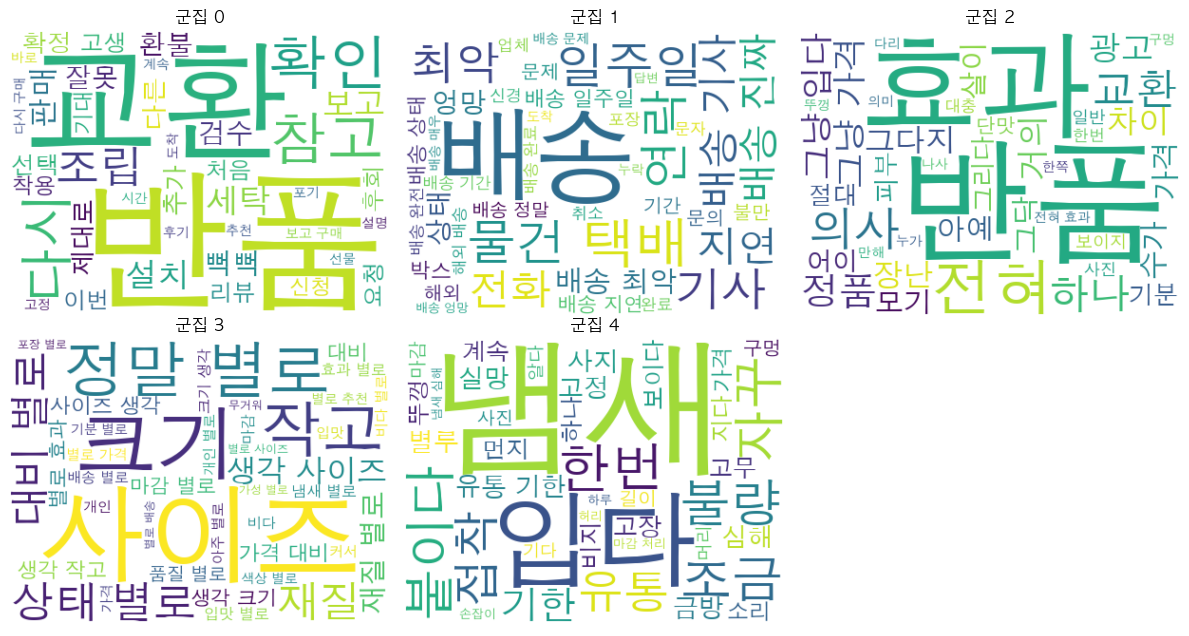

In [46]:
cols = 3
rows = (N_CLUSTERS + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3.2))
axes = axes.flatten() if N_CLUSTERS > 1 else [axes]
for c in range(N_CLUSTERS):
    freqs = {t: w for t, w in top_terms(centers_distinct[c], feature_names, 40, is_noun) if w > 0}
    wc = WordCloud(font_path=FONT_PATH, background_color="white", width=400, height=300)
    wc = wc.generate_from_frequencies(freqs)
    axes[c].imshow(wc, interpolation="bilinear"); axes[c].set_title(f"군집 {c}"); axes[c].axis("off")
for j in range(N_CLUSTERS, len(axes)):
    axes[j].axis("off")
plt.tight_layout(); plt.show()

### 7. 불만 유형별 빈도 — CS 개선 우선순위

군집 크기 = 해당 불만 유형의 리뷰 수. 가장 큰 군집부터 CS 리소스를 투입하면 된다는 **데이터 기반 우선순위**를 제시한다.

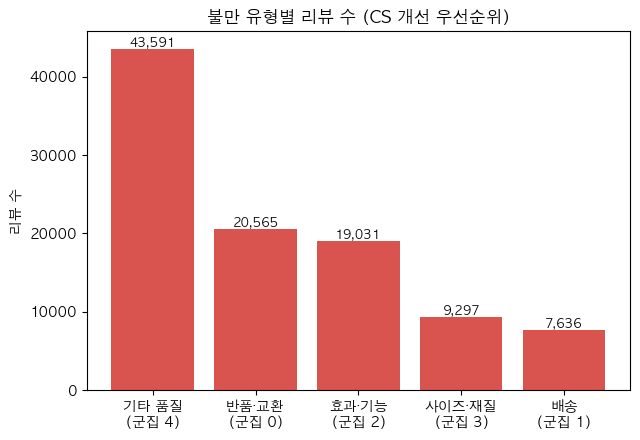

In [47]:
# 군집 라벨 - 군집별 상위 키워드를 보고 직접 해석해 붙인 유형명
CLUSTER_LABELS = {
    0: "반품·교환",
    1: "배송",
    2: "효과·기능",
    3: "사이즈·재질",
    4: "기타 품질",
}

items = sorted(summary.items(), key=lambda kv: kv[1]["size"], reverse=True)
labels_bar = [f"{CLUSTER_LABELS[c]}\n(군집 {c})" for c, v in items]
sizes = [v["size"] for _, v in items]

plt.figure(figsize=(max(6, len(items)*1.3), 4.5))
bars = plt.bar(labels_bar, sizes, color="#d9534f")
plt.title("불만 유형별 리뷰 수 (CS 개선 우선순위)"); plt.ylabel("리뷰 수")
for bar, s in zip(bars, sizes):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f"{s:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

### 8. 부정 리뷰 군집화 결과

감성모델이 부정으로 예측한 리뷰 약 100,120건을 K-Means로 **5개 불만 유형**으로 자동 분류했고, 군집 크기 순으로 CS 개선 우선순위가 드러났다.

| 순위 | 불만 유형 | 리뷰 수 | 대표 키워드 |
|---|---|---|---|
| 1 | 📦 기타 품질 (catch-all) | 43,591 | 냄새·불량·접착·유통기한 |
| 2 | 🔄 반품·교환 | 20,565 | 반품·교환·환불·검수 |
| 3 | 💊 효과·기능 | 19,031 | 효과·전혀·차이·정품 |
| 4 | 🏷️ 품질·가성비 | 9,297 | 사이즈·재질·가격 대비 |
| 5 | 🚚 배송 | 7,636 | 배송·택배·기사·지연 |

- **구체적 불만 중에서는 '반품·교환'이 가장 큰 비중**을 차지해, 사후처리(환불·교환) 프로세스 개선이 우선순위가 높음을 시사한다.
- **'배송'은 규모는 작지만 키워드가 가장 응집**(배송·택배·기사·지연으로 명확)되어, 가장 또렷하게 식별·개선 가능한 영역이다.
- 가장 큰 군집인 '기타 품질'(44%)은 특정 주제로 묶이지 않는 **포괄 불만**으로, 단일 키워드로 설명되지 않는 복합 불만이 현실의 절반 가까이임을 보여준다.